# GVC cost propagation, provenance, and welfare validation limits

**How can we distinguish a solved trade counterfactual from an unsupported welfare claim?**

This tutorial uses small generated tables with OECD ICIO, FIGARO and EXIOBASE layouts. They are synthetic teaching inputs, not observations from those databases.

## The method in math

For fixed input coefficients $A$, unit-cost propagation obeys $dp=(I-A^T)^{-1}dv$. This holds factor prices fixed. General equilibrium also changes factor prices, quantities, transfers and tax receipts. A small numerical residual certifies only that the specified equations were solved.

## Intuition

**Intuition.** A supplier cost increase reaches customers through input purchases. Similar synthetic tables can produce similar cascades by construction; that is not empirical agreement between databases. Equivalent variation requires an independently specified expenditure function and baseline utility.

## Worked code

Generate the data explicitly and display their source before reporting results.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo = Path.cwd() if (Path.cwd() / "puremacro").is_dir() else Path.cwd().parent
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))
sys.path.insert(0, str(repo / "notebooks"))
import _nbstyle
_nbstyle.apply_style()
from puremacro.trade.data import generate_synthetic_mrio, package_mrio_to_calibration_result
from puremacro.trade import calibrate_trade_model, solve_trade_equilibrium, compute_hicksian_welfare
from puremacro.trade.regularize import compute_spectral_radius

### Provenance

Real-data loaders now require a source file by default. The optional `fallback_to_synthetic=True` is an explicit opt-in. Calibrations retain provenance, unit conversions and balancing adjustments. Their default labor/capital split is a modeling assumption.

In [2]:
calibrations = {}
for source in ("oecd", "figaro", "exiobase"):
    raw = generate_synthetic_mrio(source, custom_c=3, custom_s=3, seed=42)
    calibrations[source] = package_mrio_to_calibration_result(raw)
provenance = pd.DataFrame([
    {"layout": name, "source": c.metadata["source"], "synthetic": c.metadata["is_synthetic"],
     "seed": c.metadata["seed"], "unit": c.metadata["unit"], "year": c.metadata["year"]}
    for name, c in calibrations.items()
])
print(provenance.to_string(index=False))
assert provenance["synthetic"].all()

  layout             source  synthetic  seed  unit  year
    oecd     Synthetic_OECD       True    42 M_USD  2019
  figaro   Synthetic_FIGARO       True    42 M_USD  2019
exiobase Synthetic_EXIOBASE       True    42 M_USD  2019


### Fixed-price cost propagation

The spectral upper bound checks productivity for these nonnegative coefficient matrices. The linear-system residual checks this calculation, not a welfare theorem.

In [3]:
network_rows = []
shock_size = 0.01  # ← change this
assert 0 < shock_size < 1
for name, c in calibrations.items():
    size = c.n_countries * c.n_sectors
    A = c.a.reshape(size, size, order="F")
    rho, lower, upper = compute_spectral_radius(A)
    assert upper < 1.0
    shock = np.zeros(size); shock[0] = shock_size
    # Fixed-coefficient unit-cost propagation, with factor prices held fixed.
    price_change = np.linalg.solve(np.eye(size) - A.T, shock)
    residual = np.max(np.abs((np.eye(size) - A.T) @ price_change - shock))
    assert residual < 1e-10
    network_rows.append({"layout": name, "rho": rho, "rho_upper": upper,
                         "max_cost_change": price_change.max(), "residual": residual})
network = pd.DataFrame(network_rows).set_index("layout")
print(network.to_string())

               rho  rho_upper  max_cost_change      residual
layout                                                      
oecd      0.386996   0.386996         0.012555  6.776264e-20
figaro    0.386996   0.386996         0.012555  2.168404e-19
exiobase  0.386996   0.386996         0.012555  2.032879e-20


### A solved tariff experiment

Use a separate hand-balanced two-country teaching table with consumption and investment explicitly identified. The generated provider-layout tables above illustrate networks; they are not the source of this welfare benchmark. First report nominal GDP and tariff revenue, then evaluate consumption welfare.

In [4]:
# Separate hand-balanced teaching economy: two countries, C and investment.
Z = np.array([[10., 12.], [8., 14.]])
F = np.array([[30., 8., 20., 20.], [15., 15., 50., 18.]])
production_tax = np.array([4., 6.])
va = Z.sum(1) + F.sum(1) - Z.sum(0) - production_tax
table = np.vstack([np.hstack([Z, F]), np.r_[production_tax, [2., 1., 3., 2.]],
                   np.r_[2*va/3, np.zeros(4)], np.r_[va/3, np.zeros(4)]])
c = calibrate_trade_model(table, ns=1, nc=2, nfd=2, country_codes=["A", "B"])
base = solve_trade_equilibrium(c, method="condensed", accounting="consistent", tol=1e-10)
rates = np.zeros(c.n_countries); rates[0] = 0.10
counterfactual = solve_trade_equilibrium(c, tau=rates, tau_fd=rates,
                                        method="condensed", accounting="consistent", tol=1e-10, base_result=base)
assert base.converged and counterfactual.converged
outcomes = pd.DataFrame({
    "country": c.country_codes,
    "nominal_GDP_change_pct": 100 * (counterfactual.gdp / base.gdp - 1),
    "tariff_revenue": counterfactual.tariffs,
})
print(outcomes.to_string(index=False))
print("Maximum equilibrium residual:", counterfactual.max_residual)
# Exact Hicksian equivalent variation is not inferred from GDP or revenue.
# The historical decompose_hicksian_ev_3way TOT/Alloc labels remain quarantined.

country  nominal_GDP_change_pct  tariff_revenue
      A                3.614671        3.809993
      B                0.852835        0.000000
Maximum equilibrium residual: 8.384404281969182e-13


### Hicksian consumption welfare

Category 0 is the consumption basket; investment is excluded. With one Leontief basket, utility is its quantity and the expenditure function is $e(P,U)=PU$. Thus $EV=P_0(C_1-C_0)$, positive for gains. The general interface also supports Cobb–Douglas preferences over explicitly selected consumption categories. Fiscal transfers include duties exactly once. The price/factor-income/transfer attribution is an endpoint accounting exercise, not a causal TOT/efficiency theorem.

In [5]:
welfare_results = [compute_hicksian_welfare(c, counterfactual, base_result=base,
                                           target_country=i) for i in range(c.n_countries)]
outcomes["EV_pct_consumption"] = [r.ev_pct_consumption for r in welfare_results]
welfare_table = pd.DataFrame([
    {"country": r.country_code, "EV": r.ev, "CV": r.cv,
     "prices": r.price_effect, "factor_income": r.factor_income_effect,
     "fiscal_transfers": r.fiscal_transfer_effect, "residual": r.decomposition_residual}
    for r in welfare_results
])
for i, r in enumerate(welfare_results):
    direct_ev = base.Pfd_final[0, 0, i] * (counterfactual.c_fd[0, 0, i] - base.c_fd[0, 0, i])
    np.testing.assert_allclose(r.ev, direct_ev, atol=1e-8)
print(welfare_table.to_string(index=False))

country       EV       CV    prices  factor_income  fiscal_transfers      residual
      A 0.000892 0.000925 -1.668385      -0.471069          2.140346 -1.687539e-14
      B 0.224063 0.225283 -0.396821       0.560299          0.060586  4.218847e-15


### Display the numerical results

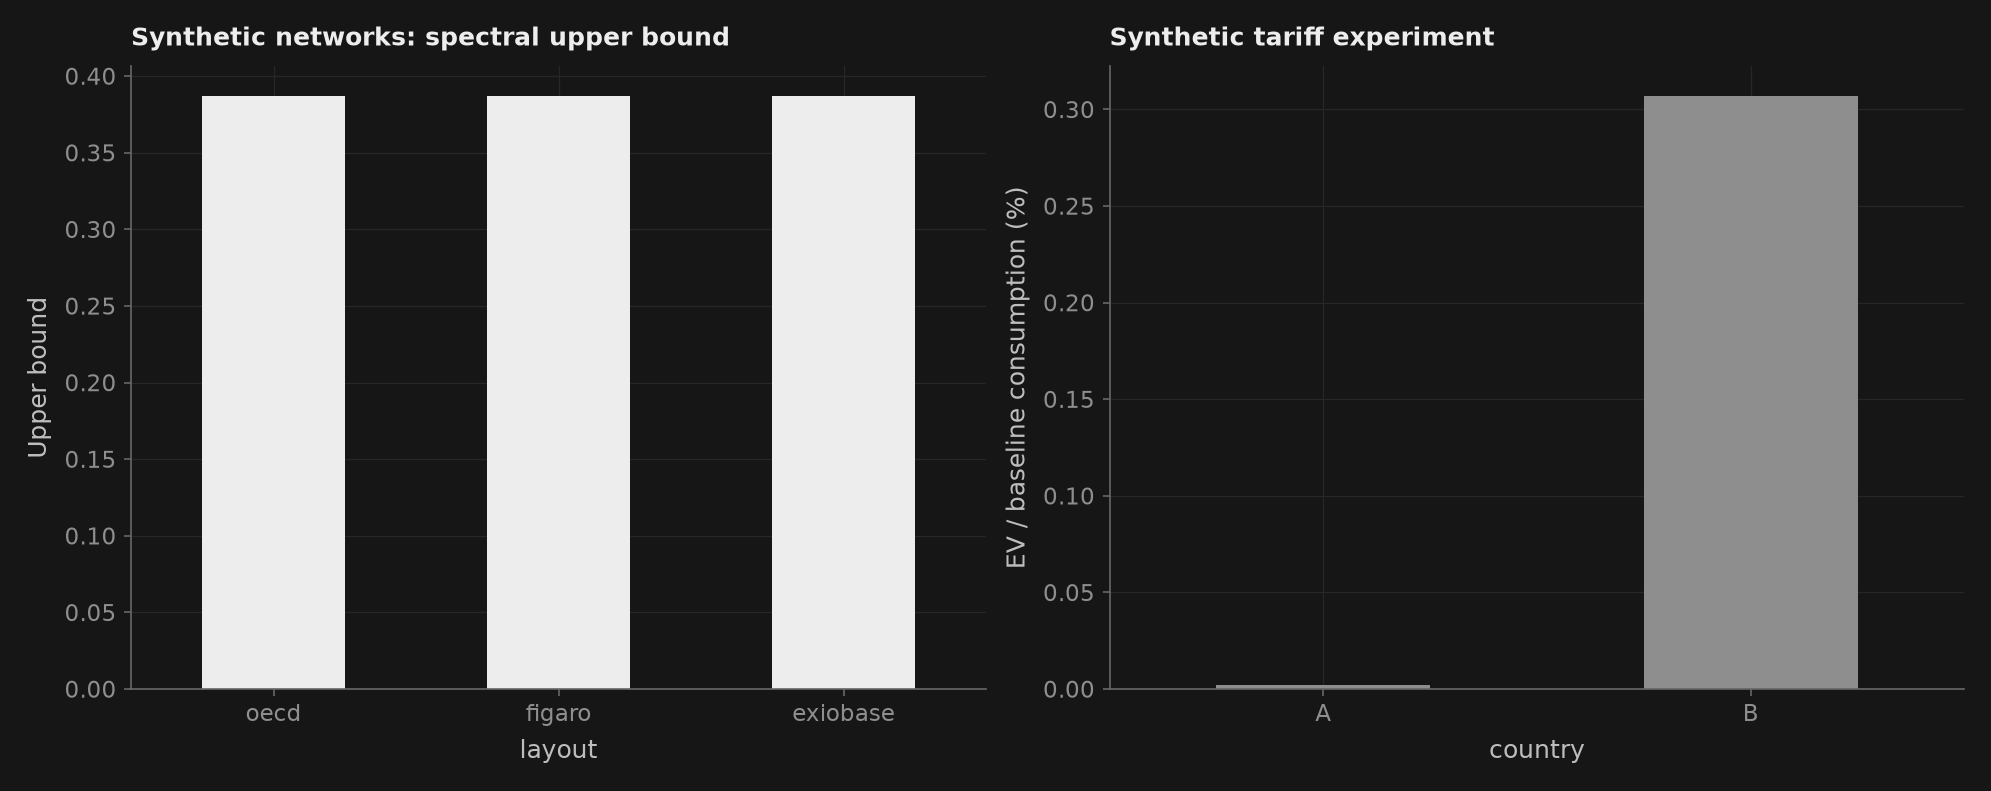

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
network["rho_upper"].plot.bar(ax=axes[0], color=_nbstyle.TINTA, rot=0)
axes[0].set(title="Synthetic networks: spectral upper bound", ylabel="Upper bound")
outcomes.set_index("country")["EV_pct_consumption"].plot.bar(ax=axes[1], color=_nbstyle.NOTA, rot=0)
axes[1].set(title="Synthetic tariff experiment", ylabel="EV / baseline consumption (%)")
axes[1].axhline(0, color=_nbstyle.SPINE, linewidth=.6)
plt.show()

## Read the output

The tables identify all inputs as synthetic. The model residual and spectral bounds are separate diagnostics. Hicksian consumption EV/CV now comes from an explicit expenditure function, checked against direct quantity valuation. The new attribution uses purchaser prices, factor income and fiscal transfers. Historical TOT/Alloc decomposition and theorem certification remain unavailable.

## Your turn

Repeat the cost experiment with a different seed or input node. Compare CES and Leontief counterfactuals using the same tariff schedules, fiscal closure and convergence tolerance. Check the returned flows against each technology before interpreting differences.

## How comprehensive is this?

This is a teaching example of provenance, fixed-coefficient propagation and a small GE solve. It does not validate native MRIO archive ingestion, empirical cross-database welfare rankings, a Nash equilibrium, or a causal TOT/efficiency decomposition. Consumption EV is conditional on the stated preferences and fiscal closure. See `docs/STRUCTURAL_VALIDATION_STATUS.md` for current validation limits.